In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [2]:
# ------------------------------------------------------------
# 1. Make a simple 2D toy dataset
# ------------------------------------------------------------
def make_toy_data(n_bkg=10000, n_sig_main=1000, n_sig_tail=150, random_state=42):
    rng = np.random.default_rng(random_state)

    # Background: broad cloud near origin
    xb1 = rng.normal(loc=[0.0, 0.0], scale=[1.2, 1.0], size=(n_bkg, 2))

    # Signal main: overlaps somewhat with background
    xs1 = rng.normal(loc=[1.8, 1.8], scale=[0.8, 0.8], size=(n_sig_main, 2))

    # Signal tail: small region farther away
    xs2 = rng.normal(loc=[3.2, 0.2], scale=[0.35, 0.35], size=(n_sig_tail, 2))

    X = np.vstack([xb1, xs1, xs2])
    y = np.hstack([
        np.zeros(len(xb1), dtype=int),
        np.ones(len(xs1), dtype=int),
        np.ones(len(xs2), dtype=int)
    ])

    # Mock event weights:
    # background weight = 1
    # main signal weight = 1
    # tail signal weight = 15   <-- strongly emphasized region
    w = np.hstack([
        np.ones(len(xb1)),
        np.ones(len(xs1)),
        np.full(len(xs2), 15.0)
    ])

    return X, y, w



In [3]:

# ------------------------------------------------------------
# 2. Build a tiny DNN
# ------------------------------------------------------------
def make_model(input_dim=2, lr=1e-3):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model


# ------------------------------------------------------------
# 3. Plot training history
# ------------------------------------------------------------
def plot_history(history, title="Training"):
    plt.figure(figsize=(6, 4))
    plt.plot(history.history["loss"], label="train loss")
    if "val_loss" in history.history:
        plt.plot(history.history["val_loss"], label="val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 4. Plot 2D decision boundary
# ------------------------------------------------------------
def plot_decision_boundary(model, X, y, sample_weight=None, scaler=None,
                           title="Decision Boundary", grid_points=300):
    x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
    y_min, y_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, grid_points),
        np.linspace(y_min, y_max, grid_points)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_scaled = scaler.transform(grid) if scaler is not None else grid

    zz = model.predict(grid_scaled, verbose=0).reshape(xx.shape)

    plt.figure(figsize=(7, 6))

    # Filled probability contours
    contour = plt.contourf(xx, yy, zz, levels=50, alpha=0.75)
    plt.colorbar(contour, label="Predicted P(signal)")

    # Decision boundary at 0.5
    plt.contour(xx, yy, zz, levels=[0.5], colors="k", linewidths=2)

    # Marker size optionally reflects sample weight
    if sample_weight is None:
        s = 18 * np.ones(len(y))
    else:
        sw = np.asarray(sample_weight)
        s = 10 + 8 * np.sqrt(sw)

    plt.scatter(
        X[y == 0, 0], X[y == 0, 1],
        s=s[y == 0], alpha=0.6, label="Background"
    )
    plt.scatter(
        X[y == 1, 0], X[y == 1, 1],
        s=s[y == 1], alpha=0.6, label="Signal"
    )

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 5. Compare weighted vs non-weighted boundary side-by-side
# ------------------------------------------------------------
def plot_boundary_comparison(model_a, model_b, X, y, scaler=None,
                             title_a="Non-weighted", title_b="Weighted",
                             grid_points=300):
    x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
    y_min, y_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, grid_points),
        np.linspace(y_min, y_max, grid_points)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_scaled = scaler.transform(grid) if scaler is not None else grid

    zz_a = model_a.predict(grid_scaled, verbose=0).reshape(xx.shape)
    zz_b = model_b.predict(grid_scaled, verbose=0).reshape(xx.shape)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)

    for ax, zz, title in zip(axes, [zz_a, zz_b], [title_a, title_b]):
        cf = ax.contourf(xx, yy, zz, levels=50, alpha=0.75)
        ax.contour(xx, yy, zz, levels=[0.5], colors="k", linewidths=2)

        ax.scatter(X[y == 0, 0], X[y == 0, 1], s=14, alpha=0.6, label="Background")
        ax.scatter(X[y == 1, 0], X[y == 1, 1], s=14, alpha=0.6, label="Signal")

        ax.set_xlabel("x1")
        ax.set_ylabel("x2")
        ax.set_title(title)

    axes[1].legend()
    fig.colorbar(cf, ax=axes.ravel().tolist(), label="Predicted P(signal)")
    #plt.tight_layout()
    plt.show()



In [4]:
# ------------------------------------------------------------
# 6. Main runnable example
# ------------------------------------------------------------
# reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# data
X, y, w = make_toy_data()

# split
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, w, test_size=0.3, random_state=42, stratify=y
)

# scale features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# ------------------------------------------------------------
# Non-weighted training
# ------------------------------------------------------------
model_nowt = make_model()

hist_nowt = model_nowt.fit(
    X_train_s, y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=256,
    verbose=0
)

# ------------------------------------------------------------
# Weighted training
# ------------------------------------------------------------
model_wt = make_model()

hist_wt = model_wt.fit(
    X_train_s, y_train,
    sample_weight=w_train,
    validation_split=0.2,
    epochs=40,
    batch_size=256,
    verbose=0
)


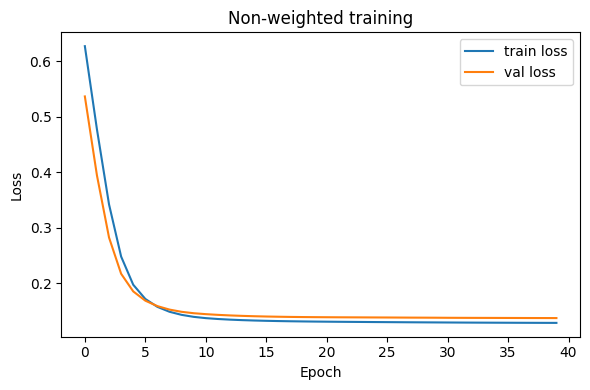

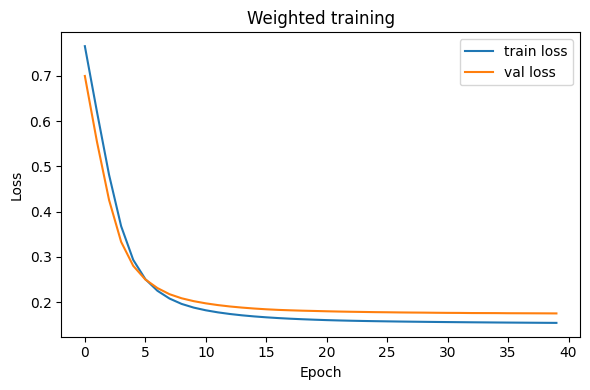

In [5]:

# ------------------------------------------------------------
# Plots
# ------------------------------------------------------------
plot_history(hist_nowt, "Non-weighted training")
plot_history(hist_wt, "Weighted training")

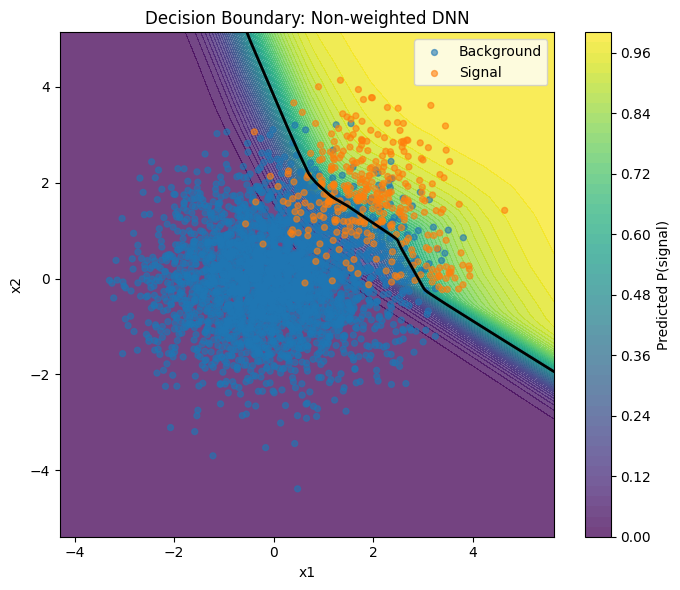

In [6]:
plot_decision_boundary(
    model_nowt, X_test, y_test,
    sample_weight=None,
    scaler=scaler,
    title="Decision Boundary: Non-weighted DNN"
)


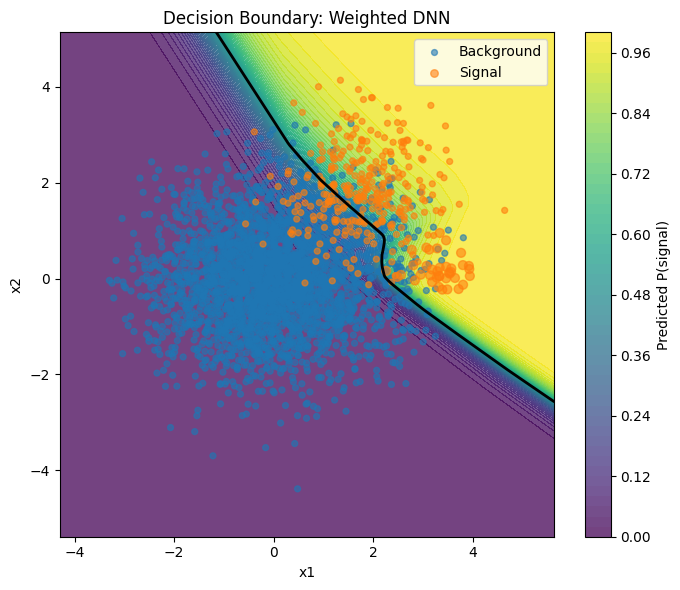

In [7]:
plot_decision_boundary(
    model_wt, X_test, y_test,
    sample_weight=w_test,
    scaler=scaler,
    title="Decision Boundary: Weighted DNN"
)

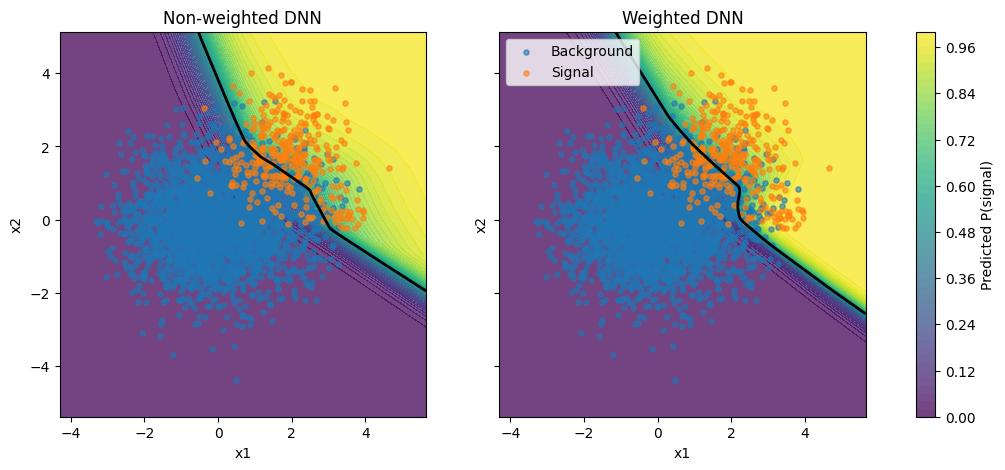

In [8]:
plot_boundary_comparison(
    model_nowt, model_wt, X_test, y_test,
    scaler=scaler,
    title_a="Non-weighted DNN",
    title_b="Weighted DNN"
)

In [9]:
from sklearn.metrics import roc_curve, auc


def _get_scores(model, X):
    """
    Return 1D score array from a Keras model.
    Assumes binary classifier with sigmoid output.
    """
    y_score = model.predict(X, verbose=0).ravel()
    return y_score


def _plot_score_distribution(ax, y_true, y_score, title, sample_weight=None, bins=40):
    """
    Plot DNN score distributions for signal and background on a given axis.
    """
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    sig_mask = (y_true == 1)
    bkg_mask = (y_true == 0)

    sig_weights = None if sample_weight is None else np.asarray(sample_weight)[sig_mask]
    bkg_weights = None if sample_weight is None else np.asarray(sample_weight)[bkg_mask]

    ax.hist(
        y_score[bkg_mask],
        bins=bins,
        range=(0, 1),
        density=True,
        histtype="step",
        linewidth=2,
        label="Background",
        weights=bkg_weights,
    )
    ax.hist(
        y_score[sig_mask],
        bins=bins,
        range=(0, 1),
        density=True,
        histtype="step",
        linewidth=2,
        label="Signal",
        weights=sig_weights,
    )

    ax.set_xlabel("DNN score")
    ax.set_ylabel("Normalized events")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)


def _plot_roc(ax, y_true, y_score, title, sample_weight=None):
    """
    Plot ROC curve on a given axis.
    """
    fpr, tpr, _ = roc_curve(y_true, y_score, sample_weight=sample_weight)
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.4f}")
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)


def plot_weighted_vs_unweighted_grid(
    model_unweighted,
    model_weighted,
    X_test,
    y_test,
    test_weights=None,
    bins=40,
    figsize=(12, 10),
):
    """
    Make a 2x2 grid:
      [0,0] Unweighted model score
      [0,1] Weighted model score
      [1,0] Unweighted model ROC
      [1,1] Weighted model ROC

    Parameters
    ----------
    model_unweighted : trained Keras model
    model_weighted   : trained Keras model
    X_test           : test features
    y_test           : true binary labels
    test_weights     : optional event weights for weighted plotting / ROC
    bins             : number of bins for score histograms
    figsize          : matplotlib figure size
    """
    # Scores
    score_unweighted = _get_scores(model_unweighted, X_test)
    score_weighted = _get_scores(model_weighted, X_test)

    fig, axes = plt.subplots(2, 2, figsize=figsize)

    # Top row: score distributions
    _plot_score_distribution(
        axes[0, 0],
        y_test,
        score_unweighted,
        title="Unweighted training: DNN score",
        sample_weight=None,
        bins=bins,
    )

    _plot_score_distribution(
        axes[0, 1],
        y_test,
        score_weighted,
        title="Weighted training: DNN score",
        sample_weight=test_weights,
        bins=bins,
    )

    # Bottom row: ROC curves
    _plot_roc(
        axes[1, 0],
        y_test,
        score_unweighted,
        title="Unweighted training: ROC",
        sample_weight=None,
    )

    _plot_roc(
        axes[1, 1],
        y_test,
        score_weighted,
        title="Weighted training: ROC",
        sample_weight=test_weights,
    )

    plt.tight_layout()
    plt.show()

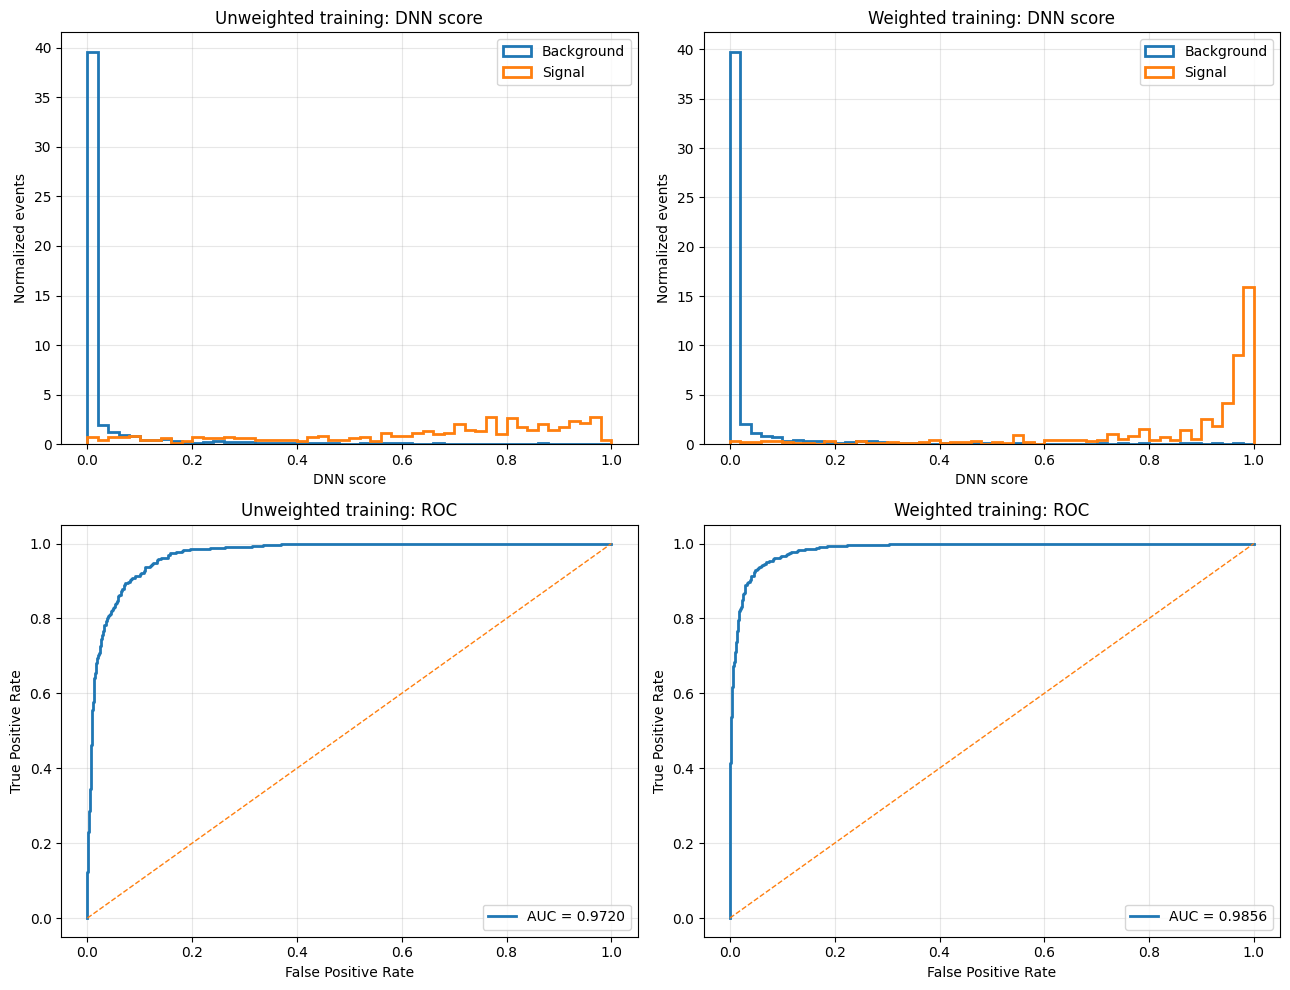

In [10]:
plot_weighted_vs_unweighted_grid(
    model_unweighted=model_nowt,
    model_weighted=model_wt,
    X_test=X_test_s,
    y_test=y_test,
    test_weights=w_test,
    bins=50,
    figsize=(13, 10),
)

In [21]:

def _get_bin_edges(x, bins=40, x_range=None):
    if x_range is None:
        xmin, xmax = np.min(x), np.max(x)
        pad = 0.05 * (xmax - xmin) if xmax > xmin else 1.0
        xmin -= pad
        xmax += pad
    else:
        xmin, xmax = x_range
    return np.linspace(xmin, xmax, bins + 1)


def _normalize_hist_counts(counts, edges):
    widths = np.diff(edges)
    total = np.sum(counts * widths)
    if total > 0:
        counts = counts / total
    return counts


def _hist_with_errors(values, bins, weights=None, density=True):
    """
    Return histogram counts and statistical uncertainties.
    For weighted case:
        variance per bin = sum(w_i^2)
    """
    values = np.asarray(values)

    if weights is None:
        weights = np.ones_like(values, dtype=float)
    else:
        weights = np.asarray(weights, dtype=float)

    counts, edges = np.histogram(values, bins=bins, weights=weights)
    sumw2, _ = np.histogram(values, bins=bins, weights=weights**2)

    errors = np.sqrt(sumw2)

    if density:
        widths = np.diff(edges)
        norm = np.sum(counts * widths)
        if norm > 0:
            counts = counts / norm
            errors = errors / norm

    centers = 0.5 * (edges[:-1] + edges[1:])
    return centers, counts, errors, edges


def _draw_step_with_band(ax, values, bins, weights=None, label="", density=True, filled=False, alpha=0.25):
    centers, counts, errors, edges = _hist_with_errors(values, bins=bins, weights=weights, density=density)

    # step line
    ax.step(edges[:-1], counts, where="post", linewidth=2, label=label)

    # error band
    ax.fill_between(
        centers,
        np.clip(counts - errors, 0, None),
        counts + errors,
        step="mid",
        alpha=alpha
    )

    # optional filled histogram look
    if filled:
        ax.hist(
            values,
            bins=bins,
            weights=weights,
            density=density,
            histtype="stepfilled",
            alpha=0.15
        )


def plot_hep_style_inputs(
    X,
    y,
    weights=None,
    feature_names=("Feature 1", "Feature 2"),
    bins_1d=40,
    bins_2d=60,
    figsize=(14, 10),
    signal_scatter_size=18,
):
    """
    HEP-style summary plot for a 2-feature toy problem.

    Layout:
      [0,0] 2D unweighted
      [0,1] 2D weighted
      [1,0] 1D projections unweighted
      [1,1] 1D projections weighted

    Parameters
    ----------
    X : array-like of shape (N,2)
    y : array-like of shape (N,)
        0 = background, 1 = signal
    weights : array-like of shape (N,) or None
    feature_names : tuple(str, str)
    bins_1d : int
    bins_2d : int
    figsize : tuple
    signal_scatter_size : float
    """

    X = np.asarray(X)
    y = np.asarray(y)

    if X.ndim != 2 or X.shape[1] != 2:
        raise ValueError("X must have shape (N, 2)")
    if len(y) != len(X):
        raise ValueError("y must have same length as X")

    if weights is not None:
        weights = np.asarray(weights, dtype=float)
        if len(weights) != len(X):
            raise ValueError("weights must have same length as X")

    x1 = X[:, 0]
    x2 = X[:, 1]

    bkg = (y == 0)
    sig = (y == 1)

    # common ranges for fair comparison
    x1_edges = _get_bin_edges(x1, bins=bins_1d)
    x2_edges = _get_bin_edges(x2, bins=bins_1d)

    x1_min, x1_max = x1_edges[0], x1_edges[-1]
    x2_min, x2_max = x2_edges[0], x2_edges[-1]

    fig, axes = plt.subplots(3, 2, figsize=figsize)

    # =========================
    # (0,0) 2D unweighted
    # =========================
    ax = axes[0, 0]

    h = ax.hist2d(
        x1[bkg],
        x2[bkg],
        bins=bins_2d,
        range=[[x1_min, x1_max], [x2_min, x2_max]],
        cmap="Blues",
        alpha=0.85
    )

    ax.scatter(
        x1[sig],
        x2[sig],
        s=signal_scatter_size,
        marker="o",
        facecolors="none",
        edgecolors="red",
        linewidths=1.0,
        label="Signal"
    )

    ax.set_title("Input space: unweighted")
    ax.set_xlabel(feature_names[0])
    ax.set_ylabel(feature_names[1])
    ax.set_xlim(x1_min, x1_max)
    ax.set_ylim(x2_min, x2_max)
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)

    cbar = fig.colorbar(h[3], ax=ax)
    cbar.set_label("Background entries")

    # =========================
    # (0,1) 2D weighted
    # =========================
    ax = axes[0, 1]

    h = ax.hist2d(
        x1[bkg],
        x2[bkg],
        bins=bins_2d,
        range=[[x1_min, x1_max], [x2_min, x2_max]],
        weights=None if weights is None else weights[bkg],
        cmap="Blues",
        alpha=0.85
    )

    if weights is None:
        sig_sizes = np.full(np.sum(sig), signal_scatter_size)
    else:
        ws = weights[sig]
        if np.max(ws) > 0:
            sig_sizes = signal_scatter_size * (0.6 + 1.8 * ws / np.max(ws))
        else:
            sig_sizes = np.full(np.sum(sig), signal_scatter_size)

    ax.scatter(
        x1[sig],
        x2[sig],
        s=sig_sizes,
        marker="o",
        facecolors="none",
        edgecolors="red",
        linewidths=1.0,
        label="Signal"
    )

    ax.set_title("Input space: weighted")
    ax.set_xlabel(feature_names[0])
    ax.set_ylabel(feature_names[1])
    ax.set_xlim(x1_min, x1_max)
    ax.set_ylim(x2_min, x2_max)
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)

    cbar = fig.colorbar(h[3], ax=ax)
    cbar.set_label("Weighted background entries")

    #Feature 1
    
    # =========================
    # (1,0) 1D unweighted
    # =========================
    ax = axes[1, 0]

    _draw_step_with_band(ax, x1[bkg], bins=x1_edges, weights=None, label=f"Bkg: {feature_names[0]}", density=True, filled=True)
    _draw_step_with_band(ax, x1[sig], bins=x1_edges, weights=None, label=f"Sig: {feature_names[0]}", density=True, filled=False)

    ax.set_title("1D projections: unweighted")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("A.U.")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, ncol=2)

    # =========================
    # (1,1) 1D weighted
    # =========================
    ax = axes[1, 1]

    w_bkg = None if weights is None else weights[bkg]
    w_sig = None if weights is None else weights[sig]

    _draw_step_with_band(ax, x1[bkg], bins=x1_edges, weights=w_bkg, label=f"Bkg: {feature_names[0]}", density=True, filled=True)
    _draw_step_with_band(ax, x1[sig], bins=x1_edges, weights=w_sig, label=f"Sig: {feature_names[0]}", density=True, filled=False)

    ax.set_title("1D projections: weighted")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("A.U.")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, ncol=2)

    # Feature 2
    
    # =========================
    # (2,0) 1D unweighted
    # =========================
    ax = axes[2, 0]

    _draw_step_with_band(ax, x2[bkg], bins=x2_edges, weights=None, label=f"Bkg: {feature_names[1]}", density=True, filled=True)
    _draw_step_with_band(ax, x2[sig], bins=x2_edges, weights=None, label=f"Sig: {feature_names[1]}", density=True, filled=False)

    ax.set_title("1D projections: unweighted")
    ax.set_xlabel("Feature 2")
    ax.set_ylabel("A.U.")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, ncol=2)

    # =========================
    # (2,1) 1D weighted
    # =========================
    ax = axes[2, 1]
    
    _draw_step_with_band(ax, x2[bkg], bins=x2_edges, weights=w_bkg, label=f"Sig/Bkg: {feature_names[1]}" if False else f"Bkg: {feature_names[1]}", density=True, filled=True)
    _draw_step_with_band(ax, x2[sig], bins=x2_edges, weights=w_sig, label=f"Sig: {feature_names[1]}", density=True, filled=False)

    ax.set_title("1D projections: weighted")
    ax.set_xlabel("Feature 2")
    ax.set_ylabel("A.U.")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, ncol=2)

    
    plt.tight_layout()
    plt.show()

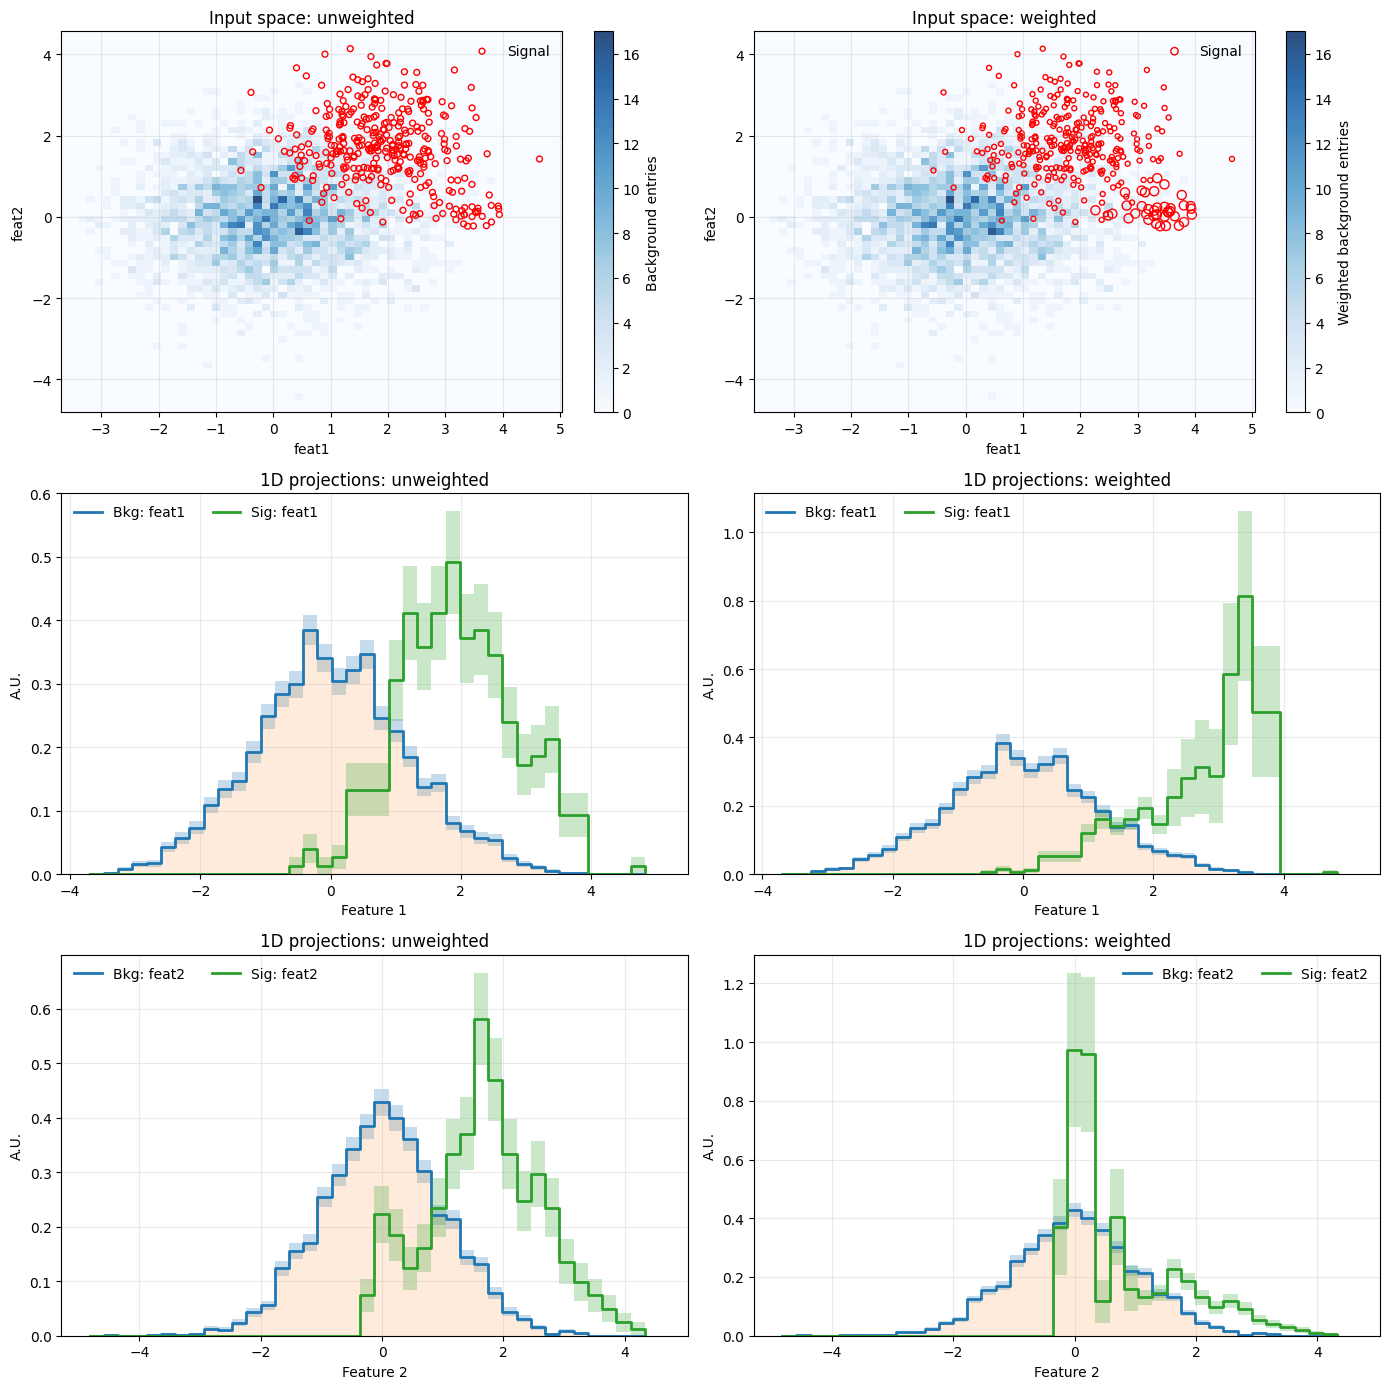

In [22]:
plot_hep_style_inputs(
    X=X_test,
    y=y_test,
    weights=w_test,
    feature_names=("feat1", "feat2"),
    bins_1d=40,
    bins_2d=60,
    figsize=(14, 14),
)

In [30]:
def _print_yield_table(results):
    """
    Nicely formatted text table (HEP-style).
    """

    header = f"{'Dataset':<10} {'Class':<12} {'Unweighted':>12} {'Weighted':>15}"
    print(header)
    print("-" * len(header))

    for dataset in ["Train", "Test"]:
        for cls, vals in results[dataset].items():
            print(f"{dataset:<10} {cls:<12} {vals['count']:>12d} {vals['weight']:>15.3f}")
def summarize_yields_np(
    y_train,
    y_test,
    w_train=None,
    w_test=None,
    label_map={0: "Background", 1: "Signal"},
    print_table=True
):
    """
    Summarize yields for train/test datasets (no pandas).

    Returns:
        results : dict
            {
              "Train": {...},
              "Test": {...}
            }
    """

    def compute(y, w):
        y = np.asarray(y)

        if w is None:
            w = np.ones_like(y, dtype=float)
        else:
            w = np.asarray(w, dtype=float)

        classes = np.unique(y)

        data = {}
        total_count = len(y)
        total_weight = np.sum(w)

        for cls in classes:
            mask = (y == cls)

            count = np.sum(mask)
            weight_sum = np.sum(w[mask])

            data[label_map.get(cls, str(cls))] = {
                "count": int(count),
                "weight": float(weight_sum),
            }

        data["Total"] = {
            "count": int(total_count),
            "weight": float(total_weight),
        }

        return data

    results = {
        "Train": compute(y_train, w_train),
        "Test": compute(y_test, w_test),
    }

    if print_table:
        _print_yield_table(results)

    return results



In [31]:
results = summarize_yields_np(
    y_train,
    y_test,
    w_train=w_train,
    w_test=w_test
)

Dataset    Class          Unweighted        Weighted
----------------------------------------------------
Train      Background           7000        7000.000
Train      Signal                805        2373.000
Train      Total                7805        9373.000
Test       Background           3000        3000.000
Test       Signal                345         877.000
Test       Total                3345        3877.000


In [37]:
def _get_model_scores(model, X):
    """
    Get 1D classifier scores from a Keras binary classifier.
    """
    return model.predict(X, verbose=0).ravel()


def _scan_significance(y_true, y_score, weights=None, n_thresholds=200):
    """
    Compute S, B, and significance as a function of score threshold.

    Selection:
        keep events with score >= threshold

    Returns
    -------
    thresholds : np.ndarray
    s_vals     : np.ndarray
    b_vals     : np.ndarray
    z_vals     : np.ndarray
    """
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    if weights is None:
        weights = np.ones_like(y_score, dtype=float)
    else:
        weights = np.asarray(weights, dtype=float)

    thresholds = np.linspace(0.0, 1.0, n_thresholds)

    s_vals = np.zeros_like(thresholds)
    b_vals = np.zeros_like(thresholds)
    z_vals = np.zeros_like(thresholds)

    sig_mask = (y_true == 1)
    bkg_mask = (y_true == 0)

    for i, thr in enumerate(thresholds):
        sel = (y_score >= thr)

        S = np.sum(weights[sel & sig_mask])
        B = np.sum(weights[sel & bkg_mask])

        s_vals[i] = S
        b_vals[i] = B
        z_vals[i] = S / np.sqrt(B) if B > 0 else 0.0

    return thresholds, s_vals, b_vals, z_vals


def _summary_dict(thresholds, s_vals, b_vals, z_vals):
    """
    Build useful summary quantities.
    """
    imax = np.argmax(z_vals)

    thr_best = thresholds[imax]
    s_best = s_vals[imax]
    b_best = b_vals[imax]
    z_best = z_vals[imax]

    return {
        "best_threshold": float(thr_best),
        "best_S": float(s_best),
        "best_B": float(b_best),
        "best_Z": float(z_best),
        "n_valid": int(np.sum(b_vals > 0)),
    }


def _draw_summary_text(ax, summary, title_prefix=""):
    """
    Draw summary numbers inside plot.
    """
    text = (
        f"{title_prefix}\n"
        f"best threshold = {summary['best_threshold']:.3f}\n"
        f"S = {summary['best_S']:.2f}\n"
        f"B = {summary['best_B']:.2f}\n"
        f"S/sqrt(B) = {summary['best_Z']:.3f}"
    )

    ax.text(
        0.97, 0.97, text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
        fontsize=10,
    )


def plot_significance_vs_threshold(
    y_true,
    score_unweighted,
    score_weighted,
    weights=None,
    n_thresholds=200,
    figsize=(12, 5),
):
    """
    Plot significance vs threshold for unweighted and weighted cases.

    Parameters
    ----------
    y_true : array-like
        True labels (0=bkg, 1=sig)
    score_unweighted : array-like
        Scores from model trained without weights
    score_weighted : array-like
        Scores from model trained with weights
    weights : array-like or None
        Event weights for weighted significance
    n_thresholds : int
        Number of scanned score thresholds
    """
    y_true = np.asarray(y_true)
    score_unweighted = np.asarray(score_unweighted)
    score_weighted = np.asarray(score_weighted)

    if weights is not None:
        weights = np.asarray(weights, dtype=float)

    # Unweighted scan
    thr_u, s_u, b_u, z_u = _scan_significance(
        y_true=y_true,
        y_score=score_unweighted,
        weights=None,
        n_thresholds=n_thresholds,
    )
    sum_u = _summary_dict(thr_u, s_u, b_u, z_u)

    # Weighted scan
    thr_w, s_w, b_w, z_w = _scan_significance(
        y_true=y_true,
        y_score=score_weighted,
        weights=weights,
        n_thresholds=n_thresholds,
    )
    sum_w = _summary_dict(thr_w, s_w, b_w, z_w)

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # -----------------------------
    # Left: unweighted
    # -----------------------------
    ax = axes[0]
    ax.plot(thr_u, z_u, linewidth=2, label="Unweighted significance")
    ax.axvline(sum_u["best_threshold"], linestyle="--", linewidth=1.5,
               label=f"Best thr = {sum_u['best_threshold']:.3f}")
    ax.set_xlabel("DNN score threshold")
    ax.set_ylabel(r"$S/\sqrt{B}$")
    ax.set_title("Unweighted significance scan")
    ax.grid(alpha=0.3)
    ax.legend(frameon=False)
    _draw_summary_text(ax, sum_u, title_prefix="Unweighted")

    # -----------------------------
    # Right: weighted
    # -----------------------------
    ax = axes[1]
    ax.plot(thr_w, z_w, linewidth=2, label="Weighted significance")
    ax.axvline(sum_w["best_threshold"], linestyle="--", linewidth=1.5,
               label=f"Best thr = {sum_w['best_threshold']:.3f}")
    ax.set_xlabel("DNN score threshold")
    ax.set_ylabel(r"$S/\sqrt{B}$")
    ax.set_title("Weighted significance scan")
    ax.grid(alpha=0.3)
    ax.legend(frameon=False)
    _draw_summary_text(ax, sum_w, title_prefix="Weighted")

    plt.tight_layout()
    plt.show()

    return {
        "unweighted": {
            "thresholds": thr_u,
            "S": s_u,
            "B": b_u,
            "Z": z_u,
            "summary": sum_u,
        },
        "weighted": {
            "thresholds": thr_w,
            "S": s_w,
            "B": b_w,
            "Z": z_w,
            "summary": sum_w,
        },
    }

def plot_significance_from_models(
    model_unweighted,
    model_weighted,
    X_test,
    y_test,
    w_test=None,
    n_thresholds=200,
    figsize=(12, 5),
):
    """
    Convenience wrapper:
      - gets scores from both models
      - makes significance scan plots
    """
    score_unweighted = _get_model_scores(model_unweighted, X_test)
    score_weighted = _get_model_scores(model_weighted, X_test)

    return plot_significance_vs_threshold(
        y_true=y_test,
        score_unweighted=score_unweighted,
        score_weighted=score_weighted,
        weights=w_test,
        n_thresholds=n_thresholds,
        figsize=figsize,
    )    

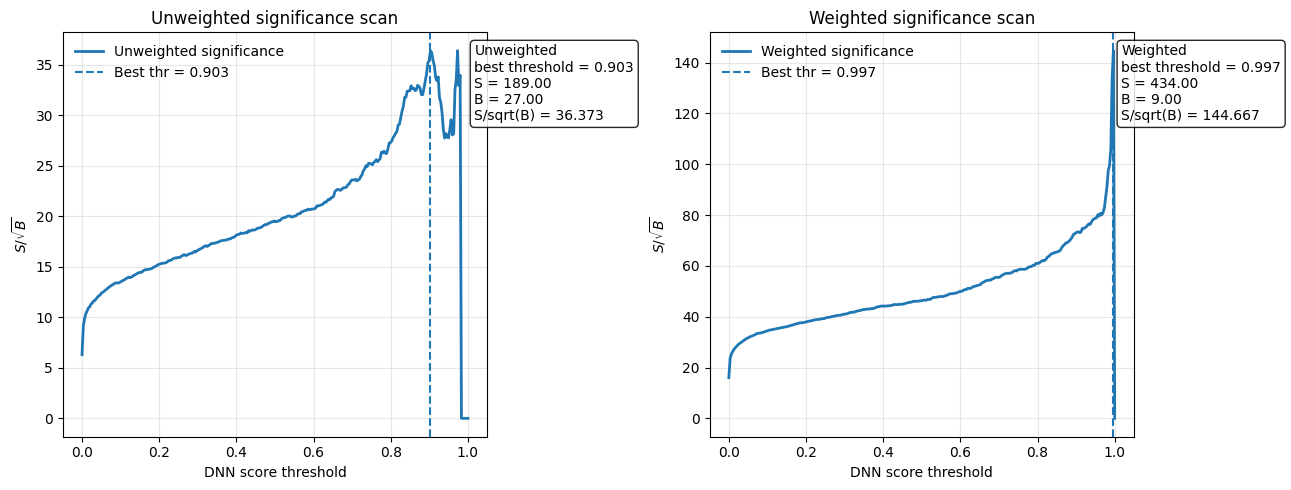

In [38]:
results = plot_significance_from_models(
    model_unweighted=model_nowt,
    model_weighted=model_wt,
    X_test=X_test,
    y_test=y_test,
    w_test=w_test,
    n_thresholds=300,
    figsize=(13, 5),
)